In [1]:
pip install earthaccess pandas numpy h5py tqdm matplotlib xarray netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 19.9 MB/s  0:00:00

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import earthaccess

# Autenticación con NASA Earthdata Login
auth = earthaccess.login(strategy="interactive", persist=True)

# Zona Metropolitana de la Ciudad de México / Valle de México
LON_MIN = -99.80
LAT_MIN = 18.80
LON_MAX = -98.50
LAT_MAX = 20.35

bbox_zmvm = (LON_MIN, LAT_MIN, LON_MAX, LAT_MAX)

# Búsqueda de granules diarios
results = earthaccess.search_data(
    short_name="OMNO2d",
    version="003",
    temporal=("2005-01-01", "2024-12-31"),
    bounding_box=bbox_cdmx
)

print(f"Archivos encontrados: {len(results)}")

Archivos encontrados: 7282


In [6]:
import earthaccess

auth = earthaccess.login(strategy="interactive", persist=True)

In [7]:
files = earthaccess.download(
    results,
    local_path="data/raw/OMNO2d_ZMCDMX_2005_2024"
)

QUEUEING TASKS | : 100%|████████████████| 7282/7282 [00:00<00:00, 379250.29it/s]
PROCESSING TASKS | : 100%|██████████████████| 7282/7282 [29:46<00:00,  4.08it/s]
COLLECTING RESULTS | : 100%|███████████| 7282/7282 [00:00<00:00, 2060508.79it/s]


In [8]:
from pathlib import Path

RAW_DIR = Path("data/raw/OMNO2d_ZMCDMX_2005_2024")

files = sorted(
    list(RAW_DIR.glob("*.he5")) +
    list(RAW_DIR.glob("*.h5")) +
    list(RAW_DIR.glob("*.nc")) +
    list(RAW_DIR.glob("*.nc4"))
)

len(files), files[0], files[-1]

(7282,
 PosixPath('data/raw/OMNO2d_ZMCDMX_2005_2024/OMI-Aura_L3-OMNO2d_2005m0101_v003-2019m1120t182907.he5'),
 PosixPath('data/raw/OMNO2d_ZMCDMX_2005_2024/OMI-Aura_L3-OMNO2d_2024m1231_v003-2025m0217t120709.he5'))

In [9]:
import h5py

sample_file = files[0]
print(sample_file)

with h5py.File(sample_file, "r") as f:
    def print_structure(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(name, obj.shape, obj.dtype)

    f.visititems(print_structure)

data/raw/OMNO2d_ZMCDMX_2005_2024/OMI-Aura_L3-OMNO2d_2005m0101_v003-2019m1120t182907.he5
HDFEOS/GRIDS/ColumnAmountNO2/Data Fields/ColumnAmountNO2 (720, 1440) float32
HDFEOS/GRIDS/ColumnAmountNO2/Data Fields/ColumnAmountNO2CloudScreened (720, 1440) float32
HDFEOS/GRIDS/ColumnAmountNO2/Data Fields/ColumnAmountNO2Trop (720, 1440) float32
HDFEOS/GRIDS/ColumnAmountNO2/Data Fields/ColumnAmountNO2TropCloudScreened (720, 1440) float32
HDFEOS/GRIDS/ColumnAmountNO2/Data Fields/Weight (720, 1440) float32
HDFEOS INFORMATION/StructMetadata.0 () |S32000


In [10]:
from pathlib import Path
import re
import h5py
import numpy as np
import pandas as pd
from tqdm import tqdm

RAW_DIR = Path("data/raw/OMNO2d_ZMCDMX_2005_2024")
OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

VAR_NAME = "ColumnAmountNO2TropCloudScreened"

# Caja amplia para la Zona Metropolitana de la CDMX
LON_MIN = -99.80
LAT_MIN = 18.80
LON_MAX = -98.50
LAT_MAX = 20.35


def infer_date_from_filename(filename):
    """
    Extrae fechas tipo 2005m0101 desde los nombres de archivos OMI.
    """
    match = re.search(r"(\d{4})m(\d{2})(\d{2})", filename)
    if match is None:
        return pd.NaT

    year, month, day = match.groups()
    return pd.Timestamp(f"{year}-{month}-{day}")


def find_dataset(h5obj, target_name):
    """
    Busca recursivamente un dataset cuyo nombre contenga target_name.
    """
    matches = []

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset) and target_name in name:
            matches.append(name)

    h5obj.visititems(visitor)

    if len(matches) == 0:
        return None

    return matches[0]


def read_scalar_attr(attrs, names, default=None):
    """
    Lee atributos tipo ScaleFactor, Offset, MissingValue, etc.
    """
    for name in names:
        if name in attrs:
            value = attrs[name]
            if isinstance(value, np.ndarray):
                if value.size == 1:
                    return value.item()
                return value
            return value
    return default


def clean_omi_array(data, attrs):
    """
    Limpia valores faltantes y aplica escala/offset si existen.
    """
    data = np.array(data, dtype=float)

    fill_value = read_scalar_attr(
        attrs,
        ["_FillValue", "MissingValue", "missing_value", "FillValue"],
        default=None
    )

    if fill_value is not None:
        data[data == fill_value] = np.nan

    # Valores extremadamente negativos o positivos suelen ser faltantes
    data[data < -1e20] = np.nan
    data[data > 1e30] = np.nan

    scale = read_scalar_attr(attrs, ["ScaleFactor", "scale_factor"], default=1.0)
    offset = read_scalar_attr(attrs, ["Offset", "add_offset"], default=0.0)

    data = data * scale + offset

    valid_range = read_scalar_attr(attrs, ["ValidRange", "valid_range"], default=None)

    if valid_range is not None and len(valid_range) == 2:
        vmin, vmax = valid_range
        data[(data < vmin) | (data > vmax)] = np.nan

    return data


def make_lat_lon_grid(data):
    """
    Construye malla regular global de 0.25 grados para OMNO2d.
    La forma esperada es 720 x 1440: latitudes x longitudes.
    """
    if data.shape == (720, 1440):
        data_std = data
    elif data.shape == (1440, 720):
        data_std = data.T
    else:
        data_std = data

    nlat, nlon = data_std.shape

    lat = np.linspace(-90 + 90/nlat, 90 - 90/nlat, nlat)
    lon = np.linspace(-180 + 180/nlon, 180 - 180/nlon, nlon)

    return data_std, lat, lon


def weighted_nanmean_by_lat(subset, lat_subset):
    """
    Promedio espacial ponderado por cos(lat).
    En esta región la diferencia con el promedio simple será pequeña,
    pero es metodológicamente más correcto.
    """
    weights_lat = np.cos(np.deg2rad(lat_subset))
    weights = weights_lat[:, None] * np.ones(subset.shape[1])

    mask = np.isfinite(subset)

    if mask.sum() == 0:
        return np.nan

    return np.nansum(subset * weights) / np.nansum(weights * mask)


records = []

files = sorted(
    list(RAW_DIR.glob("*.he5")) +
    list(RAW_DIR.glob("*.h5")) +
    list(RAW_DIR.glob("*.nc")) +
    list(RAW_DIR.glob("*.nc4"))
)

for file in tqdm(files):
    date = infer_date_from_filename(file.name)

    try:
        with h5py.File(file, "r") as f:
            dataset_path = find_dataset(f, VAR_NAME)

            if dataset_path is None:
                records.append({
                    "date": date,
                    "no2_mean": np.nan,
                    "no2_mean_weighted": np.nan,
                    "no2_median": np.nan,
                    "no2_min": np.nan,
                    "no2_max": np.nan,
                    "n_pixels": 0,
                    "status": "variable_not_found",
                    "source_file": file.name
                })
                continue

            ds = f[dataset_path]
            data = clean_omi_array(ds[...], ds.attrs)

            while data.ndim > 2:
                data = data[0]

            data, lat, lon = make_lat_lon_grid(data)

            lat_mask = (lat >= LAT_MIN) & (lat <= LAT_MAX)
            lon_mask = (lon >= LON_MIN) & (lon <= LON_MAX)

            subset = data[np.ix_(lat_mask, lon_mask)]
            lat_subset = lat[lat_mask]

            n_pixels = np.isfinite(subset).sum()

            records.append({
                "date": date,
                "no2_mean": np.nanmean(subset),
                "no2_mean_weighted": weighted_nanmean_by_lat(subset, lat_subset),
                "no2_median": np.nanmedian(subset),
                "no2_min": np.nanmin(subset),
                "no2_max": np.nanmax(subset),
                "n_pixels": n_pixels,
                "status": "ok",
                "source_file": file.name
            })

    except Exception as e:
        records.append({
            "date": date,
            "no2_mean": np.nan,
            "no2_mean_weighted": np.nan,
            "no2_median": np.nan,
            "no2_min": np.nan,
            "no2_max": np.nan,
            "n_pixels": 0,
            "status": f"error: {e}",
            "source_file": file.name
        })


df_daily = pd.DataFrame(records)
df_daily = df_daily.sort_values("date").reset_index(drop=True)

output_file = OUT_DIR / "no2_zmcdmx_daily_2005_2024.csv"
df_daily.to_csv(output_file, index=False)

df_daily.head(), output_file

  0%|                                         | 14/7282 [00:00<01:52, 64.34it/s]/var/folders/m_/8mzkz3rs33d6yq5r8q03bc9r0000gn/T/ipykernel_2875/3070826292.py:184: RuntimeWarning: Mean of empty slice
  "no2_mean": np.nanmean(subset),
/var/folders/m_/8mzkz3rs33d6yq5r8q03bc9r0000gn/T/ipykernel_2875/3070826292.py:186: RuntimeWarning: All-NaN slice encountered
  "no2_median": np.nanmedian(subset),
/var/folders/m_/8mzkz3rs33d6yq5r8q03bc9r0000gn/T/ipykernel_2875/3070826292.py:187: RuntimeWarning: All-NaN slice encountered
  "no2_min": np.nanmin(subset),
/var/folders/m_/8mzkz3rs33d6yq5r8q03bc9r0000gn/T/ipykernel_2875/3070826292.py:188: RuntimeWarning: All-NaN slice encountered
  "no2_max": np.nanmax(subset),
100%|███████████████████████████████████████| 7282/7282 [01:48<00:00, 67.07it/s]


(        date      no2_mean  no2_mean_weighted    no2_median       no2_min  \
 0 2005-01-01  3.980617e+15       3.976124e+15  3.675069e+15  1.154053e+15   
 1 2005-01-02  3.983353e+15       3.979158e+15  2.424481e+15  4.102561e+13   
 2 2005-01-03  5.899898e+15       5.895981e+15  6.384993e+15  1.865273e+15   
 3 2005-01-04  7.503897e+15       7.498970e+15  4.622024e+15  4.954176e+14   
 4 2005-01-05  8.716332e+15       8.714297e+15  7.568528e+15  1.977366e+15   
 
         no2_max  n_pixels status  \
 0  8.215667e+15        30     ok   
 1  1.090659e+16        30     ok   
 2  1.063718e+16        30     ok   
 3  2.493877e+16        30     ok   
 4  2.112087e+16        30     ok   
 
                                          source_file  
 0  OMI-Aura_L3-OMNO2d_2005m0101_v003-2019m1120t18...  
 1  OMI-Aura_L3-OMNO2d_2005m0102_v003-2019m1120t18...  
 2  OMI-Aura_L3-OMNO2d_2005m0103_v003-2019m1120t18...  
 3  OMI-Aura_L3-OMNO2d_2005m0104_v003-2019m1120t18...  
 4  OMI-Aura_L3-OMNO2d_200

In [11]:
df_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 7282 entries, 0 to 7281
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               7282 non-null   datetime64[us]
 1   no2_mean           5401 non-null   float64       
 2   no2_mean_weighted  5401 non-null   float64       
 3   no2_median         5401 non-null   float64       
 4   no2_min            5401 non-null   float64       
 5   no2_max            5401 non-null   float64       
 6   n_pixels           7282 non-null   int64         
 7   status             7282 non-null   str           
 8   source_file        7282 non-null   str           
dtypes: datetime64[us](1), float64(5), int64(1), str(2)
memory usage: 910.4 KB


In [12]:
df_daily["status"].value_counts()

status
ok    7282
Name: count, dtype: int64

In [13]:
df_daily[["date", "no2_mean", "no2_mean_weighted", "n_pixels"]].describe()

,date,no2_mean,no2_mean_weighted,n_pixels
count,7282,5.401000e+03,5.401000e+03,7282.000000
mean,2014-12-31 05:42:41.823674,3.622367e+15,3.621780e+15,16.127026
min,2005-01-01 00:00:00,-7.657127e+15,-7.655049e+15,0.000000
25%,2009-12-30 06:00:00,2.174298e+15,2.173130e+15,0.000000
50%,2014-12-24 12:00:00,3.386325e+15,3.385046e+15,19.000000
75%,2020-01-04 18:00:00,4.756616e+15,4.751504e+15,30.000000
max,2024-12-31 00:00:00,1.649194e+16,1.650075e+16,30.000000
std,NaN,2.103963e+15,2.103319e+15,12.573888


In [14]:
date_range = pd.date_range("2005-01-01", "2024-12-31", freq="D")

available_dates = pd.to_datetime(df_daily["date"].dropna().unique())

missing_dates = date_range.difference(available_dates)

print("Días esperados:", len(date_range))
print("Días disponibles:", len(available_dates))
print("Días faltantes:", len(missing_dates))

missing_dates[:20]

Días esperados: 7305
Días disponibles: 7282
Días faltantes: 23


DatetimeIndex(['2006-03-01', '2006-03-02', '2008-09-28', '2008-09-29',
               '2016-05-30', '2016-05-31', '2016-06-01', '2016-06-02',
               '2016-06-03', '2016-06-04', '2016-06-05', '2016-06-06',
               '2016-06-07', '2016-06-08', '2016-06-09', '2016-06-11',
               '2016-06-12', '2017-03-13', '2017-03-14', '2017-03-15'],
              dtype='datetime64[us]', freq=None)

In [15]:
df_daily["date"] = pd.to_datetime(df_daily["date"])
df_daily["year"] = df_daily["date"].dt.year
df_daily["month"] = df_daily["date"].dt.month

df_monthly = (
    df_daily
    .groupby(["year", "month"], as_index=False)
    .agg(
        no2_mean=("no2_mean", "mean"),
        no2_mean_weighted=("no2_mean_weighted", "mean"),
        no2_median=("no2_mean", "median"),
        valid_days=("no2_mean", "count"),
        mean_pixels=("n_pixels", "mean")
    )
)

df_annual = (
    df_daily
    .groupby("year", as_index=False)
    .agg(
        no2_mean=("no2_mean", "mean"),
        no2_mean_weighted=("no2_mean_weighted", "mean"),
        no2_median=("no2_mean", "median"),
        valid_days=("no2_mean", "count"),
        mean_pixels=("n_pixels", "mean")
    )
)

df_monthly.to_csv(OUT_DIR / "no2_zmcdmx_monthly_2005_2024.csv", index=False)
df_annual.to_csv(OUT_DIR / "no2_zmcdmx_annual_2005_2024.csv", index=False)

df_monthly.head(), df_annual.head()

(   year  month      no2_mean  no2_mean_weighted    no2_median  valid_days  \
 0  2005      1  6.157922e+15       6.156478e+15  6.614888e+15          29   
 1  2005      2  4.341241e+15       4.339697e+15  4.560675e+15          26   
 2  2005      3  3.093228e+15       3.091337e+15  2.905028e+15          30   
 3  2005      4  3.868830e+15       3.868367e+15  4.104335e+15          28   
 4  2005      5  3.698545e+15       3.698823e+15  3.772054e+15          30   
 
    mean_pixels  
 0    26.516129  
 1    23.035714  
 2    22.419355  
 3    25.100000  
 4    21.677419  ,
    year      no2_mean  no2_mean_weighted    no2_median  valid_days  \
 0  2005  3.988186e+15       3.987563e+15  3.761429e+15         333   
 1  2006  3.997057e+15       3.996440e+15  3.690089e+15         332   
 2  2007  4.053486e+15       4.052876e+15  3.738874e+15         336   
 3  2008  4.221483e+15       4.220448e+15  3.730328e+15         331   
 4  2009  3.833509e+15       3.833450e+15  3.577196e+15         27

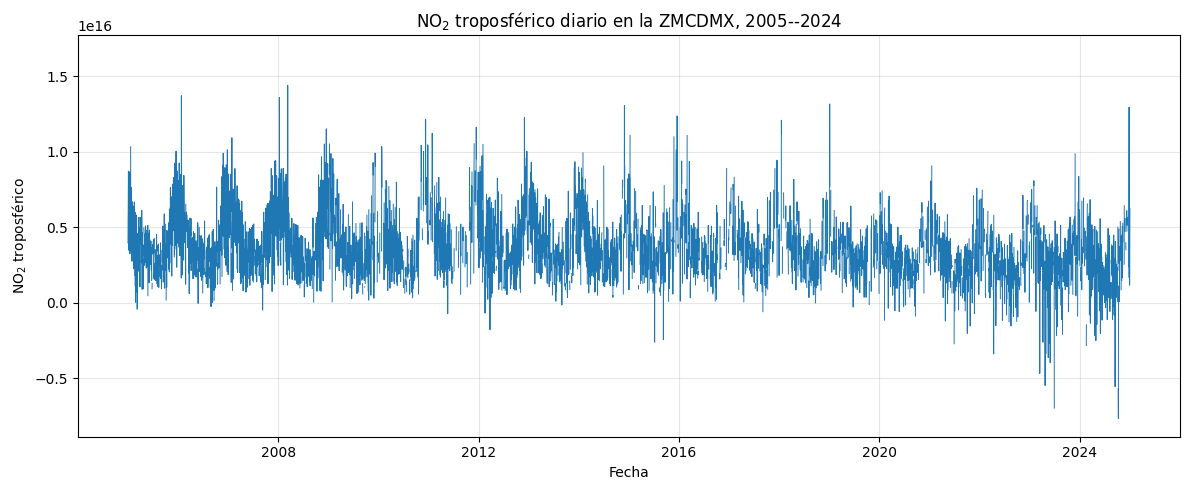

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df_daily["date"], df_daily["no2_mean_weighted"], linewidth=0.7)
plt.xlabel("Fecha")
plt.ylabel("NO$_2$ troposférico")
plt.title("NO$_2$ troposférico diario en la ZMCDMX, 2005--2024")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Los datos satelitales utilizados corresponden a campos diarios de dióxido de
nitrógeno troposférico distribuidos en una malla regular latitud--longitud.
Por lo tanto, el producto original no proporciona directamente una serie
temporal para la Zona Metropolitana de la Ciudad de México. Para construirla,
en cada fecha se seleccionan las celdas de la malla contenidas en la región de
estudio y se calcula un promedio espacial. De esta manera, a partir de una
sucesión de campos diarios se obtiene una serie temporal diaria representativa
de la concentración regional de NO$_2$ troposférico.

Si $X_i(t)$ denota el valor de NO$_2$ en la celda espacial $i$ durante el día
$t$, la serie regional se define como
$$
\overline{X}(t)
=
\frac{\sum_{i\in \mathcal{R}} w_i X_i(t)}
{\sum_{i\in \mathcal{R}} w_i},
$$
donde $\mathcal{R}$ representa el conjunto de celdas pertenecientes a la región
de estudio y $w_i=\cos(\varphi_i)$ es un peso latitudinal asociado a la celda
$i$. En una primera aproximación, $\mathcal{R}$ se toma como una ventana
rectangular que cubre la Zona Metropolitana de la Ciudad de México; en una
etapa posterior puede reemplazarse por una máscara municipal.

In [18]:
from pathlib import Path

serie_file = Path("data/processed/no2_zmcdmx_daily_2005_2024.csv")

serie_file.exists(), serie_file

(True, PosixPath('data/processed/no2_zmcdmx_daily_2005_2024.csv'))

In [ ]:
from pathlib import Path

serie_file = Path("data/processed/no2_zmcdmx_daily_2005_2024.csv")

serie_file.exists(), serie_file